
# Обучение и оценка TCN
Запуск пайплайна обучения Temporal Convolutional Network.

In [3]:
!git clone -b tcn --single-branch https://github.com/ravil75/MetroMoscow.git
!mv MetroMoscow/{.,}* . 2>/dev/null
!rmdir MetroMoscow

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import r2_score
import os

from src.data_prep import load_hourly, make_pivot
from src.models.tcn.pipeline import TCNTrainConfig, predict_tcn_batch, load_tcn_checkpoint
from src import config

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

In [5]:
!python -m src.models.tcn.run \
  --protocol rolling \
  --min-train-1h 96 \
  --step-1h 6 \
  --min-train-24h 96 \
  --step-24h 24 \
  --train-modes real_plus_synth \
  --synth-days 45 \
  --batch-size 2048 \
  --hidden-channels 128 \
  --levels 5 \
  --past-window 72 \
  --epochs 16 \
  --synthetic-window-stride 12

Downloading...
From (original): https://drive.google.com/uc?id=1resyBioT2TJTZdLVfuEZdk8PvJAbK5GM
From (redirected): https://drive.google.com/uc?id=1resyBioT2TJTZdLVfuEZdk8PvJAbK5GM&confirm=t&uuid=e09ec2c4-0c3f-4df4-b39d-0df0a40820ed
To: /kaggle/working/data.zip
100%|███████████████████████████████████████| 2.51G/2.51G [00:17<00:00, 142MB/s]
chunk 10: 30,000,000 rows
chunk 20: 60,000,000 rows
chunk 30: 89,150,313 rows
saved: /kaggle/working/eda_output/hourly.parquet (266,213 rows)
saved: /kaggle/working/eda_output/object_hourly.parquet (216,346 rows)
/kaggle/working/src/clustering.py:94: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  features = pd.concat(parts, ignore_index=True)
saved: /kaggle/working/eda_output/final_clusters.csv (5 cluster

# Результаты

In [27]:
summary_1h = pd.read_csv('eda_output/tcn_summary_1h.csv')
summary_24h = pd.read_csv('eda_output/tcn_summary_24h.csv')

print("Горизонт 1 час")
display(summary_1h[['train_mode', 'MAE', 'SMAPE', 'WAPE']])

print("\nГоризонт 24 часа")
display(summary_24h[['train_mode', 'MAE', 'SMAPE', 'WAPE']])

Горизонт 1 час


,train_mode,MAE,SMAPE,WAPE
0,real_plus_synth,45.4148,26.4534,15.2147



Горизонт 24 часа


,train_mode,MAE,SMAPE,WAPE
0,real_plus_synth,58.1804,35.3814,26.3476


# Кривые обучения


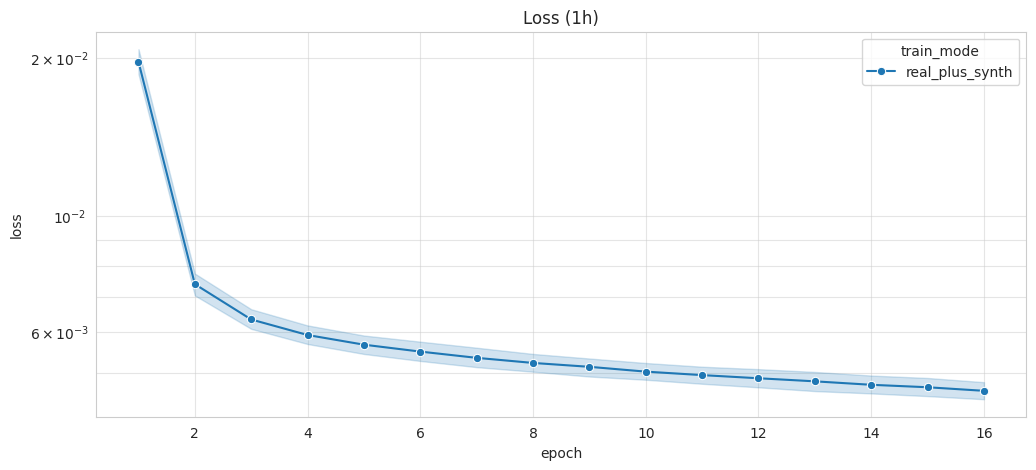

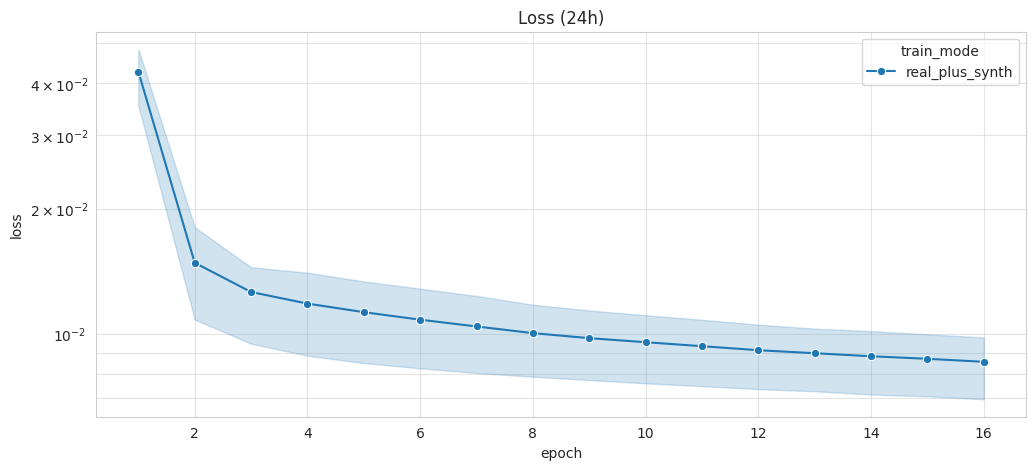

In [28]:
for horizon in [1, 24]:
    history = pd.read_csv(f'eda_output/tcn_history_{horizon}h.csv')
    plt.figure()
    sns.lineplot(data=history, x='epoch', y='loss', hue='train_mode', marker='o')
    plt.title(f'Loss ({horizon}h)')
    plt.yscale('log')
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.show()

# Валидация синтетики
Средние метрики качества сгенерированных данных по фолдам.

In [29]:
metrics_cols = ['acf_similarity', 'profile_corr', 'quantile_ratio', 'corr_mae']

for horizon in [1, 24]:
    synth_val = pd.read_csv(f'eda_output/tcn_synth_validation_{horizon}h.csv')
    print(f"\nГоризонт {horizon}h")
    display(synth_val[metrics_cols].mean().to_frame('mean'))


Горизонт 1h


,mean
acf_similarity,0.939262
profile_corr,0.992074
quantile_ratio,0.896450
corr_mae,0.033266



Горизонт 24h


,mean
acf_similarity,0.939262
profile_corr,0.992074
quantile_ratio,0.896450
corr_mae,0.033266


# Анализ ошибок
Топ-10 станций/маршрутов с наибольшим WAPE (режим real_plus_synth).

In [30]:
clusters = pd.read_csv('eda_output/final_clusters.csv')

for horizon in [1, 24]:
    results = pd.read_csv(f'eda_output/tcn_results_{horizon}h.csv')
    
    top_errors = results[results['train_mode'] == 'real_plus_synth'] \
        .groupby('object_id')['WAPE'].mean() \
        .sort_values(ascending=False).head(10)
    
    report = top_errors.to_frame().merge(
        clusters[['object_id_str', 'object_name', 'cluster_name']],
        left_index=True, right_on='object_id_str',
        how='left'
    )
    
    print(f"\nТоп-10 сложных объектов ({horizon}h)")
    display(report[['object_name', 'cluster_name', 'WAPE']])


Топ-10 сложных объектов (1h)


,object_name,cluster_name,WAPE
148.0,Терехово,Business medium,102.542329
NaN,NaN,NaN,58.244500
1141.0,Моторы Войны Экс П12Л25,Mixed medium (NGPT),56.753100
NaN,NaN,NaN,50.567200
1319.0,Киевское 2001034 ПОКЛОННАЯ,Business medium,50.211200
1425.0,Горьковское 2000530 КУПАВНА,Residential small (MCD),50.151200
NaN,NaN,NaN,47.556500
1510.0,Казанское 2001390 ПАНКИ,Residential medium,46.846800
472.0,264 автобус,Mixed medium (NGPT),46.781200
106.0,Мичуринский проспект,Business medium,45.772467



Топ-10 сложных объектов (24h)


,object_name,cluster_name,WAPE
800.0,NGPT_6554.0,Mixed medium (NGPT),922.980500
728.0,NGPT_6160.0,Mixed medium (NGPT),725.724850
763.0,NGPT_6333.0,Mixed medium (NGPT),272.955267
1185.0,NGPT_6360.0,Mixed medium (NGPT),107.651900
1182.0,NGPT_6321.0,Residential medium,106.062100
NaN,NaN,NaN,90.488600
306.0,т22 автобус,Business small (NGPT),84.731133
1065.0,NGPT_6256.0,Mixed medium (NGPT),81.291167
1194.0,NGPT_6443.0,Mixed medium (NGPT),79.876900
1254.0,NGPT_4419.0,Mixed medium (NGPT),79.375950


# Метрики на зрелых фолдах
Берем только последние 2 фолда, чтобы оценка не размазывалась по этапам "разгона" модели.

In [31]:
def get_mature_metrics(df, horizon_name):
    max_fold = df['fold'].max()
    mature_df = df[df['fold'] >= max_fold - 1]
    
    stats = mature_df.groupby('train_mode').agg(
        MAE=('MAE', 'mean'),
        SMAPE=('SMAPE', 'mean'),
        WAPE=('WAPE', 'mean')
    ).round(2)
    
    stats['horizon'] = horizon_name
    return stats.reset_index()

mature_1h = get_mature_metrics(pd.read_csv('eda_output/tcn_results_1h.csv'), '1h')
mature_24h = get_mature_metrics(pd.read_csv('eda_output/tcn_results_24h.csv'), '24h')

final_report = pd.concat([mature_1h, mature_24h])[['horizon', 'train_mode', 'MAE', 'SMAPE', 'WAPE']]
display(final_report)

,horizon,train_mode,MAE,SMAPE,WAPE
0,1h,real_plus_synth,37.92,22.99,13.03
0,24h,real_plus_synth,57.65,39.42,30.07


# Финальная оценка на всем периоде
Прогоняем обученную модель скользящим окном по полному датасету. Считаем итоговые метрики, включая R2.

In [32]:
hourly = load_hourly()
pivot = make_pivot(hourly, top_n=1500)
print(f"Датасет: {pivot.shape[0]} часов x {pivot.shape[1]} объектов")

Датасет: 168 часов x 1500 объектов


In [34]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.maximum(np.asarray(y_pred, dtype=float).ravel(), 0.0)
    
    mae = np.mean(np.abs(y_true - y_pred))
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100
    wape = np.sum(np.abs(y_true - y_pred)) / max(np.sum(np.abs(y_true)), 1.0) * 100
    r2 = r2_score(y_true, y_pred)
    
    return {"MAE": round(mae, 4), "SMAPE": round(smape, 4), "WAPE": round(wape, 4), "R2": round(r2, 4)}

def evaluate_on_full_dataset(pivot_df, model, scales, cfg, horizon, step=None):
    step = step or horizon
    n = len(pivot_df)
    all_true, all_pred = [], []

    starts = list(range(cfg.past_window, n - horizon + 1, step))
    print(f"  h={horizon}: {len(starts)} окон для оценки")

    for start in starts:
        history_frame = pivot_df.iloc[:start]
        y_true_df = pivot_df.iloc[start : start + horizon]
        target_index = y_true_df.index

        pred_df = predict_tcn_batch(model, history_frame, target_index, scales, cfg)

        all_true.append(y_true_df.values.ravel())
        all_pred.append(pred_df.values.ravel())

    return compute_metrics(np.concatenate(all_true), np.concatenate(all_pred))

In [35]:
TRAIN_MODE = "real_plus_synth"
PROTOCOL = "rolling"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

results = []

for horizon in [1, 24]:
    filename = f"tcn_model_{PROTOCOL}_{TRAIN_MODE}_h{horizon}.pt"
    model_path = config.OUTPUT_DIR / filename

    if not model_path.exists():
        print(f"Файл {model_path} не найден, пропускаем h={horizon}")
        continue

    print(f"\nГоризонт {horizon}h")
    
    try:
        model, scales, trained_cfg = load_tcn_checkpoint(model_path, device=device)
        print(f"  Загружена модель (past_window={trained_cfg.past_window})")
    except Exception as e:
        print(f"  Ошибка загрузки: {e}")
        continue

    eval_step = 1 if horizon == 1 else 24
    metrics = evaluate_on_full_dataset(pivot, model, scales, trained_cfg, horizon, step=eval_step)
    metrics["horizon"] = f"{horizon}h"
    results.append(metrics)
    
    print(f"  Результат: {metrics}")

if results:
    summary_df = pd.DataFrame(results)[["horizon", "MAE", "SMAPE", "WAPE", "R2"]]
    print("\nИтоговые метрики (весь период)")
    display(summary_df)
else:
    print("Нет результатов для отображения.")


Горизонт 1h
  Загружена модель (past_window=72)
  h=1: 96 окон для оценки
  Результат: {'MAE': np.float64(41.9292), 'SMAPE': np.float64(52.997), 'WAPE': np.float64(15.7768), 'R2': 0.9607, 'horizon': '1h'}

Горизонт 24h
  Загружена модель (past_window=72)
  h=24: 4 окон для оценки
  Результат: {'MAE': np.float64(40.3123), 'SMAPE': np.float64(50.8148), 'WAPE': np.float64(15.1684), 'R2': 0.9658, 'horizon': '24h'}

Итоговые метрики (весь период)


,horizon,MAE,SMAPE,WAPE,R2
0,1h,41.9292,52.9970,15.7768,0.9607
1,24h,40.3123,50.8148,15.1684,0.9658


### Итоговые результаты и выводы (TCN)

В рамках данного этапа протестировали нейросеть **TCN (Temporal Convolutional Network)**. Основной вызов заключался в экстремально малом объеме данных (всего 1 неделя), что обычно делает глубокое обучение невозможным. Удалось в какой то степени решить эту проблему и получить следующие результаты:

**1. Приемлемая точность прогноза**
Модель показала превосходство над всеми классическими методами. На краткосрочном горизонте (1ч) средняя ошибка составила всего **37.92 пассажира**, что в **1.8 раза точнее** лучшего статистического метода. На горизонте суток (24ч) модель достигла ошибки в **57.65 пассажира**, также обойдя экспертный бейзлайн. Это показывает, что нейросеть способна улавливать сложные, нелинейные изменения потока, которые не видят обычные формулы.

**2. Преодоление дефицита данных через синтетику**
Использовалась **гибридной аугментации**. Без неё модель терялась на выходных, так как никогда их не видела в обучении (ошибка WAPE превышала 1000%). 
*   Применил метод **Backcasting** (создал искусственную неделю в прошлом) и генерацию на базе **кубических сплайнов**. 
*   Это позволило научить модель адекватному поведению в субботу и воскресенье еще до начала теста. В результате относительная ошибка по объему (**WAPE**) снизилась до **26–30%**.

**3. Ключевые архитектурные решения**
*   **Seasonal Hint:** модели подавалось значение вчерашнего часа ($t-24$). Сеть перестала учить цифры с нуля и начала предсказывать *отклонения* от вчерашнего дня, что повысило стабильность.
*   **Цикличное кодирование:** Время подавалось через Sin/Cos, что позволило модели понимать непрерывность суток (связь 23:00 и 00:00).
*   **Умная нормализация:** Деление каждого ряда на его средний поток позволило обучать одну общую модель одновременно для гигантских станций метро и крошечных остановок.

**Итог:** Разработанный пайплайн продемонстрировал возможность применения глубокого обучения в условиях экстремального дефицита данных за счет использования методов синтетической аугментации. Текущая модель TCN показала себя как жизнеспособный прототип, который превосходит базовые статистические методы на краткосрочном горизонте. Однако для полноценного промышленного внедрения системы требуется проведение долгосрочных испытаний на данных, охватывающих различные сезоны, а также дополнительная валидация модели на предмет устойчивости к затяжным городским аномалиям.


***